# Animating Minimoons: Earth's Temporarily Captured Asteroids

#### This tutorial simulates three real minimoons from their MPC orbits, looks at their paths in three different frames of reference, and turns them into animations — both inside the notebook and as stand-alone video files for the web.

Every so often a small near-Earth asteroid drifts past Earth so slowly that, for a while, Earth's gravity wins: the object becomes a **temporarily captured orbiter** — a *minimoon* — loops around us a few times, and then wanders off again. Three such objects have been caught in the act:

| Object | Size | Story |
|---|---|---|
| **2006 RH120** | about 3 m | Discovered by the Catalina Sky Survey in September 2006; orbited Earth for about a year and left in mid-2007 |
| **2020 CD3** | about 1–2 m | Discovered by Catalina in February 2020, shortly before it left; it had been orbiting Earth, unseen, since 2017 |
| **2024 PT5** | about 10 m | Found by ATLAS in August 2024; bound to Earth for two months in late 2024 without completing a loop — a fly-through rather than an orbit |

The physics is subtle but the recipe is not. In this tutorial we:

1. fetch the three objects' orbits from the **MPC Orbits API**;
2. integrate them through their capture windows with **ASSIST**, the ephemeris-quality integrator (Sun, planets, *and* the Moon, which matters enormously here);
3. apply the standard **capture diagnostics** from the literature — geocentric energy, the Hill sphere, and the number of revolutions about Earth — to decide who is a captured orbiter and who is a fly-through;
4. draw the same trajectory in a **heliocentric**, a **geocentric** and a **Sun–Earth rotating** frame, and see why the last is the one that makes captures legible;
5. build **animations** with `matplotlib.animation`: a rotating-frame view with a distance-versus-time panel, and a heliocentric "camera" that flies in from the whole orbit to the Hill sphere and back out;
6. **render** them as MP4 and GIF files (plus a poster frame) so they can be embedded on a web page.

This notebook builds on the simpler, static tutorials in the [Working with Orbits](https://docs.minorplanetcenter.net/tutorials/orbit_tutorials/) section — [fetching an orbit and integrating it with REBOUND](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_to_rebound/), [the same with ASSIST](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_to_assist/), [plotting orbits](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_plotting/), [reference frames](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_frames/) and [Earth's co-orbital companions](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_earth_coorbitals/), which uses the same Sun–Earth rotating frame — so if any of those steps are unfamiliar, start there.

The animations here are adapted from ones made for a Minor Planet Center talk on the minimoon population. Their scientific background is in [Granvik, Vaubaillon & Jedicke (2012)](https://ui.adsabs.harvard.edu/abs/2012Icar..218..262G) and [Fedorets, Granvik & Jedicke (2017)](https://ui.adsabs.harvard.edu/abs/2017Icar..285...83F). The integration set-up is the one from the [ASSIST tutorial](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_to_assist/), which explains the coordinate conventions in detail.

## Environment Setup

This notebook requires `rebound`, `assist`, `mpc-orb`, `astropy`, `matplotlib`, `numpy`, `requests`, and — to write MP4 files — the `ffmpeg` command-line tool. We recommend creating a dedicated conda environment and registering it as a Jupyter kernel so that all dependencies are isolated and reproducible.

Run the following commands once in a terminal before opening this notebook:

```bash
# Create and populate the environment
conda create -n orbit-tutorial python=3.11 -y
conda activate orbit-tutorial
pip install rebound assist mpc-orb astropy matplotlib numpy requests ipykernel
conda install -c conda-forge ffmpeg          # for MP4 output (GIFs need only Pillow, which matplotlib brings in)

# Register the environment as a Jupyter kernel
python -m ipykernel install --user --name orbit-tutorial --display-name "Python (orbit-tutorial)"
```

If you do not already have a way of running Jupyter notebooks, also install Jupyter itself (`pip install jupyter`), then launch it from the directory containing this notebook with:

```bash
jupyter notebook
```

and open this file in the browser tab that appears. However you run the notebook, select **Kernel > Change Kernel > Python (orbit-tutorial)** before running the cells below.

If you already created the `orbit-tutorial` environment for the ASSIST tutorial, you only need `ffmpeg`. Without `ffmpeg` everything still runs except the MP4 files (and the inline videos, which are built from them); you will still get GIFs.

**N.B. In Step 2 (below) two large ephemeris files (about 770 MB in total) are downloaded once and cached, which may cause problems for users with slow connections.** They are the same files the ASSIST tutorial uses, so if you have run that notebook from this directory they are already present.

# Install and Import Packages

In [1]:
import os
import warnings
from pathlib import Path

import requests
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter
from matplotlib.patches import Circle, Rectangle
from IPython.display import HTML, Image, display

import rebound
import assist
from mpc_orb.parse import MPCORB
from astropy.time import Time

warnings.filterwarnings("ignore", message=".*Mass cannot be retrieved.*")   # rebound's Horizons lookup, Step 6

# Step 1: Fetch the Orbits from the MPC

We query the [MPC Orbits API](https://docs.minorplanetcenter.net/mpc-ops-docs/apis/get-orb/) for each object and parse the result with `mpc_orb`. We will use the Cartesian (`CAR`) state vector — heliocentric, ecliptic, ICRF-aligned — exactly as in the ASSIST tutorial.

One thing to notice in the table: the **epoch** of each orbit. The MPC keeps every orbit at an epoch near the last observations, which for 2024 PT5 is inside its capture window but for 2006 RH120 is thirteen years *after* it. We will have to integrate backwards through those years — and, as Step 6 shows, that has consequences.

In [2]:
OBJECTS = ["2006 RH120", "2020 CD3", "2024 PT5"]

def fetch_mpc_orbit(desig):
    r = requests.get("https://data.minorplanetcenter.net/api/get-orb",
                     json={"desig": desig}, timeout=60)
    r.raise_for_status()
    return MPCORB(r.json()[0]["mpc_orb"][0])

orbits = {name: fetch_mpc_orbit(name) for name in OBJECTS}

print(f"{'object':<11} {'epoch (TT)':<12} {'H':>5} {'obs':>5} {'arc':>9}")
for name, M in orbits.items():
    stats = M.orbit_fit_statistics if hasattr(M, "orbit_fit_statistics") else {}
    jd = M.epoch_data["epoch"] + 2400000.5
    print(f"{name:<11} {Time(jd, format='jd', scale='tt').iso[:10]:<12} "
          f"{M.magnitude_data['H']:>5.1f} {stats.get('nobs_total', '?'):>5} {stats.get('arc_length_total', '?'):>9}")

object      epoch (TT)       H   obs       arc
2006 RH120  2020-05-31    29.5   135  281 days
2020 CD3    2022-01-21    31.8   131   95 days
2024 PT5    2024-10-17    27.4   410  190 days


# Step 2: Download the JPL Ephemeris Files

ASSIST reads the planets, the Moon and sixteen massive asteroids from the JPL development ephemerides rather than integrating them. The two files (`de440.bsp`, about 120 MB, and `sb441-n16.bsp`, about 650 MB) are downloaded once into `assist_ephem_data/` and reused; see the [ASSIST tutorial](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_to_assist/) for details.

In [3]:
DATA_DIR = "assist_ephem_data"
os.makedirs(DATA_DIR, exist_ok=True)

EPHEM_URLS = {
    "de440.bsp":
        "https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/planets/de440.bsp",
    "sb441-n16.bsp":
        "https://ssd.jpl.nasa.gov/ftp/eph/small_bodies/asteroids_de441/sb441-n16.bsp",
}

def download_if_missing(filename, url):
    path = os.path.join(DATA_DIR, filename)
    if os.path.exists(path):
        print(f"Found existing file: {path} ({os.path.getsize(path)/1e6:.0f} MB)")
        return path
    print(f"Downloading {url}\n  -> {path}  (large file: this may take several minutes)")
    with requests.get(url, stream=True, timeout=600) as r:
        r.raise_for_status()
        with open(path + ".part", "wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                f.write(chunk)
    os.rename(path + ".part", path)
    print(f"  done ({os.path.getsize(path)/1e6:.0f} MB)")
    return path

ephem = assist.Ephem(download_if_missing("de440.bsp", EPHEM_URLS["de440.bsp"]),
                     download_if_missing("sb441-n16.bsp", EPHEM_URLS["sb441-n16.bsp"]))
print(f"\nEphemerides loaded. Reference Julian Date: JD {ephem.jd_ref}")

Found existing file: assist_ephem_data/de440.bsp (120 MB)
Found existing file: assist_ephem_data/sb441-n16.bsp (646 MB)

Ephemerides loaded. Reference Julian Date: JD 2451545.0


# Step 3: Simulate the Captures with ASSIST

Why ASSIST rather than a plain REBOUND simulation? Because a minimoon's fate is decided by the Earth–Moon system: the Moon's gravity is what nudges an approaching asteroid into a bound orbit, and it is also usually what kicks it back out. ASSIST takes the Moon (and everything else) from the DE440 ephemeris, so the simulation is as faithful as the ephemeris — and it is what the MPC itself would use to check a capture.

The conventions are those of the ASSIST tutorial: the MPC state is heliocentric ecliptic, ASSIST wants barycentric equatorial, so we rotate by the obliquity and add the Sun's barycentric state at the epoch. Two details are specific to captures:

- **Integrating in both directions.** The catalogue epoch may sit before, inside or after the capture window, so we make two passes from the epoch: one forwards through the output times after it, and one backwards (a fresh simulation integrated toward earlier times) through those before it. `exact_finish_time=1` makes REBOUND land exactly on each output time.
- **A floor on the time step.** While an object is bound to Earth the adaptive IAS15 step can shrink to microseconds and a two-year run takes minutes; a floor of 10⁻³ days (about 90 s) keeps it fast at no cost to accuracy for these orbits. Remove `min_dt` to see the difference.

`propagate` returns everything the rest of the notebook needs — the object, Earth, Moon and Sun on a common time grid, all **barycentric, ecliptic** — as a dictionary of arrays. We sample every 0.1 day, fine enough for smooth animations even at the closest approaches.

In [4]:
AU_KM = 149597870.7
LD_AU = 384400.0 / AU_KM                   # one lunar distance in AU
GM_SUN = 2.9591220828411956e-04            # DE440 GM values, AU^3 / day^2
GM_EARTH = 8.887692446707103e-10
GM_MOON = 1.093189462402435e-11

def rotate_x(v, eps):
    # Rotate (N, 3) or (3,) vectors about the x-axis by eps: ecliptic -> equatorial for eps > 0.
    v = np.atleast_2d(np.asarray(v, dtype=float))
    c, s = np.cos(eps), np.sin(eps)
    out = np.column_stack([v[:, 0], c * v[:, 1] - s * v[:, 2], s * v[:, 1] + c * v[:, 2]])
    return out[0] if out.shape[0] == 1 else out

def body_states(name, t_grid, eps):
    # Barycentric ecliptic position and velocity of an ephemeris body on the grid.
    r, v = np.empty((len(t_grid), 3)), np.empty((len(t_grid), 3))
    for k, t in enumerate(t_grid):
        p = ephem.get_particle(name, t)
        r[k], v[k] = (p.x, p.y, p.z), (p.vx, p.vy, p.vz)
    return rotate_x(r, -eps), rotate_x(v, -eps)

def propagate(M, jd_grid, min_dt=1e-3):
    # Integrate an MPC orbit with ASSIST; return states on jd_grid (barycentric, ecliptic, AU & AU/day).
    eps = np.radians(float(M.system_data["EclipticObliquityArcseconds"]) / 3600.0)
    state = np.array(M.CAR.coefficient_values[:6])
    t0 = M.epoch_data["epoch"] + 2400000.5 - ephem.jd_ref
    sun0 = ephem.get_particle("sun", t0)
    pos0 = rotate_x(state[:3], eps) + np.array([sun0.x, sun0.y, sun0.z])
    vel0 = rotate_x(state[3:], eps) + np.array([sun0.vx, sun0.vy, sun0.vz])

    t_grid = np.asarray(jd_grid, dtype=float) - ephem.jd_ref
    obj = np.empty((len(t_grid), 6))
    for direction in (+1, -1):                            # one pass forwards from the epoch, one backwards
        sel = np.flatnonzero(t_grid >= t0) if direction > 0 else np.flatnonzero(t_grid < t0)
        if len(sel) == 0:
            continue
        sim = rebound.Simulation()
        sim.add(x=pos0[0], y=pos0[1], z=pos0[2], vx=vel0[0], vy=vel0[1], vz=vel0[2])
        sim.t = t0                                        # set BEFORE attaching ASSIST
        extras = assist.Extras(sim, ephem)
        sim.ri_ias15.min_dt = min_dt
        for k in sel[np.argsort(direction * t_grid[sel])]:   # in the order the integration meets them
            sim.integrate(t_grid[k], exact_finish_time=1)
            p = sim.particles[0]
            obj[k] = (p.x, p.y, p.z, p.vx, p.vy, p.vz)

    traj = {"jd": np.asarray(jd_grid, dtype=float),
            "r_obj": rotate_x(obj[:, :3], -eps), "v_obj": rotate_x(obj[:, 3:], -eps)}
    for name in ("earth", "moon", "sun"):
        traj[f"r_{name}"], traj[f"v_{name}"] = body_states(name, t_grid, eps)
    traj["dates"] = Time(traj["jd"], format="jd", scale="tdb").to_datetime()
    return traj

# Windows that comfortably contain each capture (dates are UTC-ish; the day matters, not the second)
WINDOWS = {"2006 RH120": ("2006-01-01", "2008-01-01"),
           "2020 CD3":   ("2017-01-01", "2020-07-01"),
           "2024 PT5":   ("2024-06-01", "2025-03-01")}
CADENCE = 0.1                                             # days between samples

import time
trajectories = {}
for name in OBJECTS:
    jd_a, jd_b = (Time(d, scale="tdb").jd for d in WINDOWS[name])
    tic = time.time()
    trajectories[name] = propagate(orbits[name], np.arange(jd_a, jd_b + 1e-6, CADENCE))
    print(f"{name}: {len(trajectories[name]['jd']):,} samples from {WINDOWS[name][0]} to {WINDOWS[name][1]} "
          f"in {time.time() - tic:.0f} s")

2006 RH120: 7,301 samples from 2006-01-01 to 2008-01-01 in 1 s


2020 CD3: 12,771 samples from 2017-01-01 to 2020-07-01 in 5 s


2024 PT5: 2,731 samples from 2024-06-01 to 2025-03-01 in 0 s


# Step 4: Is It Captured? The Standard Diagnostics

"Captured" needs a definition, and the literature has settled on a simple one ([Kary & Dones 1996](https://ui.adsabs.harvard.edu/abs/1996Icar..121..207K); Granvik et al. 2012): at a given instant the object is **bound** if

- its geocentric two-body energy is negative, `E = ½ v² − GM_⊕ / r < 0` (it is moving too slowly, relative to Earth, to escape), **and**
- it is within **three Hill radii** of Earth, `r < 3 R_H`, where `R_H = d (GM_⊕ / 3 GM_☉)^{1/3} ≈ 0.01 AU ≈ 4 lunar distances` is the radius of the region in which Earth's gravity dominates the Sun's tide.

A contiguous run of bound samples is one **capture event**. Fedorets et al. (2017) then ask two more things of an event before calling it a *temporarily captured orbiter* (TCO): it must pass **within one Hill radius**, and it must complete **at least one revolution** around Earth, counted as the total change of the object's longitude about Earth *in the frame co-rotating with the Sun–Earth line* (the frame of Step 5). An event that fails the revolution test is a *temporarily captured fly-by* (TCF). The functions below implement exactly this.

In [5]:
def geocentric(traj):
    return traj["r_obj"] - traj["r_earth"], traj["v_obj"] - traj["v_earth"]

def hill_radius(traj):
    d = np.linalg.norm(traj["r_earth"] - traj["r_sun"], axis=1)
    return d * (GM_EARTH / (3.0 * GM_SUN)) ** (1.0 / 3.0)

def bound_mask(traj):
    r, v = geocentric(traj)
    dist = np.linalg.norm(r, axis=1)
    energy = 0.5 * np.sum(v * v, axis=1) - GM_EARTH / dist
    return (energy < 0) & (dist < 3.0 * hill_radius(traj))

def rotating_frame(traj):
    # Geocentric positions in the frame co-rotating with the Sun-Earth line:
    # x from the Sun through Earth (L1 at x < 0, L2 at x > 0), z the ecliptic pole. Returns (object, Moon), (N, 3).
    rse = traj["r_earth"] - traj["r_sun"]
    lam = np.arctan2(rse[:, 1], rse[:, 0])               # Earth's heliocentric longitude
    c, s = np.cos(lam), np.sin(lam)
    def rot(rg):
        return np.column_stack([c * rg[:, 0] + s * rg[:, 1], -s * rg[:, 0] + c * rg[:, 1], rg[:, 2]])
    return rot(traj["r_obj"] - traj["r_earth"]), rot(traj["r_moon"] - traj["r_earth"])

def contiguous_runs(mask):
    edges = np.diff(np.concatenate([[0], mask.astype(int), [0]]))
    return list(zip(np.flatnonzero(edges == 1), np.flatnonzero(edges == -1)))   # (start, stop) pairs, stop exclusive

def revolutions(xy):
    # Unsigned revolutions about the origin: sum of |delta longitude| / 2 pi (Fedorets et al. 2017)
    phi = np.arctan2(xy[:, 1], xy[:, 0])
    dphi = (np.diff(phi) + np.pi) % (2 * np.pi) - np.pi
    return np.sum(np.abs(dphi)) / (2 * np.pi)

def capture_summary(traj, name):
    r, _ = geocentric(traj)
    dist, rH = np.linalg.norm(r, axis=1), hill_radius(traj)
    bound = bound_mask(traj)
    rot_obj, _ = rotating_frame(traj)
    events = []
    for a, b in contiguous_runs(bound):
        inside_1RH = np.any(dist[a:b] < rH[a:b])
        revs = revolutions(rot_obj[a:b, :2])
        events.append({"start": traj["dates"][a], "end": traj["dates"][b - 1],
                       "days": (traj["jd"][b - 1] - traj["jd"][a]), "min_dist_LD": dist[a:b].min() / LD_AU,
                       "revolutions": revs, "within_1RH": inside_1RH,
                       "verdict": "TCO (orbiter)" if inside_1RH and revs >= 1 else "TCF (fly-by)"})
    return {"name": name, "bound_days": bound.sum() * CADENCE, "events": events}

summaries = {name: capture_summary(traj, name) for name, traj in trajectories.items()}
print(f"{'object':<11} {'bound from':<12} {'to':<12} {'days':>6} {'closest [LD]':>13} {'revs':>6}  verdict")
for s in summaries.values():
    for ev in s["events"]:
        print(f"{s['name']:<11} {ev['start']:%Y-%m-%d}   {ev['end']:%Y-%m-%d}   {ev['days']:6.0f} "
              f"{ev['min_dist_LD']:13.2f} {ev['revolutions']:6.2f}  {ev['verdict']}")

object      bound from   to             days  closest [LD]   revs  verdict
2006 RH120  2006-08-07   2007-09-17      406          0.86   4.04  TCO (orbiter)
2020 CD3    2017-09-15   2020-05-07      965          0.04  13.08  TCO (orbiter)
2024 PT5    2024-09-29   2024-11-25       57          9.04   0.25  TCF (fly-by)


(The *closest* column is the closest approach during the bound interval; 2024 PT5 came much closer to Earth in January 2025, after it had already been released.)

The verdicts match the stories in the introduction: 2006 RH120 and 2020 CD3 are genuine temporarily captured orbiters, with several revolutions each, and 2024 PT5 is a fly-by that never completed a loop. (2020 CD3's bound interval begins in 2017, three years before anyone saw it — a reminder that minimoons are found by luck, when they happen to pass close and bright enough for a survey.)

# Step 5: Three Frames of Reference

The same trajectory looks completely different depending on where you stand. We draw 2006 RH120 three ways:

1. **Heliocentric, inertial.** The Sun at the origin, axes fixed in space. The asteroid's orbit is so similar to Earth's that at this scale the two paths lie on top of each other; nothing about the capture is visible.
2. **Geocentric, inertial.** Earth at the origin but the axes still fixed in space. The loops around Earth now appear, but as a slowly turning rosette, because the Sun's direction keeps rotating.
3. **Sun–Earth rotating frame.** Earth at the origin *and* the axes co-rotating with the Sun–Earth line, so the Sun is always to the left. The Hill sphere and the L1 (sunward) and L2 (anti-sunward) gateways are fixed in this frame, and the path shows exactly how the object slipped in through one gateway, looped around, and left through another. This is the frame in which the capture literature counts revolutions, and the one we animate first.

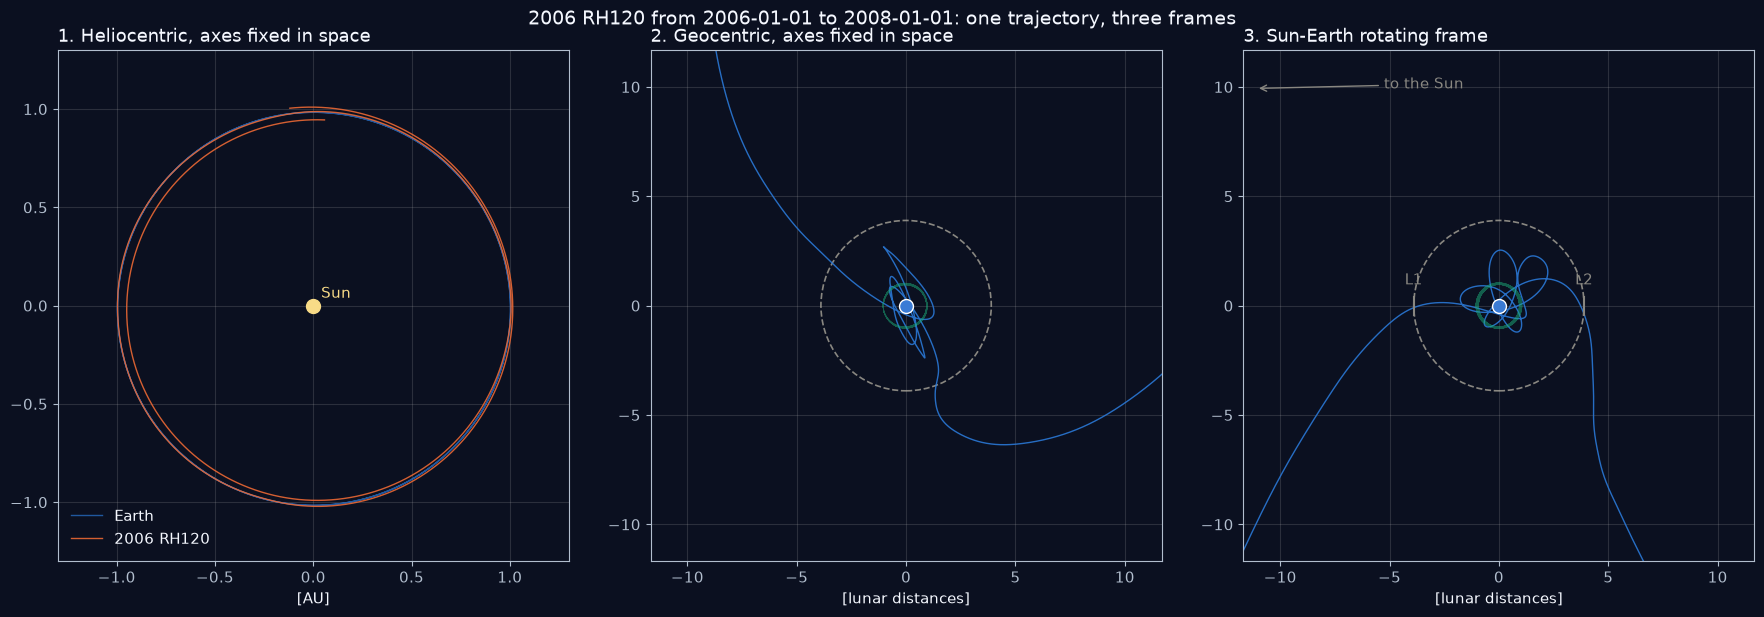

In [6]:
DARK = {"bg": "#0B1020", "ink": "#F5F8FF", "muted": "#B2BECE"}
BLUE, ORANGE, AQUA, YELLOW, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#F8DB87", "#898781"
plt.rcParams.update({"text.color": DARK["ink"], "axes.labelcolor": DARK["ink"], "xtick.color": DARK["muted"],
                     "ytick.color": DARK["muted"], "axes.edgecolor": DARK["muted"], "axes.facecolor": DARK["bg"],
                     "figure.facecolor": DARK["bg"], "savefig.facecolor": DARK["bg"], "font.size": 11})

def hill_circle(ax, radius, **kw):
    ax.add_patch(Circle((0, 0), radius, fill=False, ls="--", lw=1.2, color=GREY, **kw))

name = "2006 RH120"
traj = trajectories[name]
r_geo, _ = geocentric(traj)
rot_obj, rot_moon = rotating_frame(traj)
rH_LD = np.median(hill_radius(traj)) / LD_AU
bound = bound_mask(traj)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# 1. heliocentric, inertial
ax = axes[0]
re_, ro = traj["r_earth"] - traj["r_sun"], traj["r_obj"] - traj["r_sun"]
ax.plot(0, 0, "o", color=YELLOW, ms=10); ax.text(0.04, 0.04, "Sun", color=YELLOW)
ax.plot(re_[:, 0], re_[:, 1], color=BLUE, lw=1.0, alpha=0.7, label="Earth")
ax.plot(ro[:, 0], ro[:, 1], color=ORANGE, lw=1.0, alpha=0.9, label=name)
ax.set_aspect("equal"); ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3)
ax.set_xlabel("[AU]"); ax.set_title("1. Heliocentric, axes fixed in space", loc="left")
ax.legend(loc="lower left", framealpha=0)
# 2. geocentric, inertial
ax = axes[1]
ax.plot(r_geo[:, 0] / LD_AU, r_geo[:, 1] / LD_AU, color=BLUE, lw=1.0, alpha=0.9)
ax.plot((traj["r_moon"] - traj["r_earth"])[:, 0] / LD_AU, (traj["r_moon"] - traj["r_earth"])[:, 1] / LD_AU,
        color=AQUA, lw=0.3, alpha=0.5)
hill_circle(ax, rH_LD); ax.plot(0, 0, "o", color="#3a7bd5", ms=10, mec="white")
ax.set_aspect("equal"); ax.set_xlim(-3 * rH_LD, 3 * rH_LD); ax.set_ylim(-3 * rH_LD, 3 * rH_LD)
ax.set_xlabel("[lunar distances]"); ax.set_title("2. Geocentric, axes fixed in space", loc="left")
# 3. rotating frame
ax = axes[2]
ax.plot(rot_obj[:, 0] / LD_AU, rot_obj[:, 1] / LD_AU, color=BLUE, lw=1.0, alpha=0.9)
ax.plot(rot_moon[:, 0] / LD_AU, rot_moon[:, 1] / LD_AU, color=AQUA, lw=0.3, alpha=0.5)
hill_circle(ax, rH_LD); ax.plot(0, 0, "o", color="#3a7bd5", ms=10, mec="white")
ax.plot([-rH_LD, rH_LD], [0, 0], "|", color=GREY, ms=14, mew=1.5)
ax.text(-rH_LD, 0.25 * rH_LD, "L1", ha="center", color=GREY); ax.text(rH_LD, 0.25 * rH_LD, "L2", ha="center", color=GREY)
ax.annotate("to the Sun", xy=(-3 * rH_LD * 0.95, 3 * rH_LD * 0.85), xytext=(-3 * rH_LD * 0.45, 3 * rH_LD * 0.85),
            color=GREY, arrowprops=dict(arrowstyle="->", color=GREY))
ax.set_aspect("equal"); ax.set_xlim(-3 * rH_LD, 3 * rH_LD); ax.set_ylim(-3 * rH_LD, 3 * rH_LD)
ax.set_xlabel("[lunar distances]"); ax.set_title("3. Sun-Earth rotating frame", loc="left")
for ax in axes:
    ax.grid(alpha=0.2)
fig.suptitle(f"{name} from {WINDOWS[name][0]} to {WINDOWS[name][1]}: one trajectory, three frames", fontsize=14)
plt.tight_layout()
plt.show()

# Step 6: How Faithful Is the Simulation?

Before animating, a sanity check. JPL Horizons publishes its own trajectory for each object, fitted to the same observations, and REBOUND can fetch a Horizons state vector for a small body by name. We compare Horizons' position with ours at the **middle of each bound interval** — the moment that matters most.

The result is a lesson about epochs. 2024 PT5's MPC orbit epoch is inside its capture window, and the two solutions agree to a few kilometres. 2006 RH120's epoch is thirteen years after its capture; integrating backwards through that many years — including several later Earth encounters, each of which magnifies any tiny difference in the orbit or the force model — leaves a discrepancy of order a lunar distance by 2007. The capture is reproduced (the object is bound for about a year, loops several times, enters and leaves through the same gateways), but the loops are not the *same* loops, and no integration from a 2020 epoch could do better: this is sensitive dependence on initial conditions, not a bug. For an ephemeris-quality reconstruction of a specific old event you would start from an orbit fitted at an epoch inside the event.

In [7]:
def horizons_barycentric_ecliptic(name, jd):
    # Position of a small body from JPL Horizons via rebound (barycentric, ecliptic, AU) at a TDB Julian date.
    sim = rebound.Simulation()
    sim.units = ("AU", "day", "Msun")
    sim.add(name, date=f"JD{jd:.6f}")
    p = sim.particles[0]
    return np.array([p.x, p.y, p.z])

print(f"{'object':<11} {'epoch to check [yr]':>20} {'|ASSIST - Horizons|':>22}")
for name, traj in trajectories.items():
    ev = summaries[name]["events"][0]
    jd_mid = 0.5 * (Time(ev["start"]).jd + Time(ev["end"]).jd)
    k = np.argmin(np.abs(traj["jd"] - jd_mid))
    d_km = np.linalg.norm(traj["r_obj"][k] - horizons_barycentric_ecliptic(name, traj["jd"][k])) * AU_KM
    years = (jd_mid - (orbits[name].epoch_data["epoch"] + 2400000.5)) / 365.25
    print(f"{name:<11} {years:>20.1f} {d_km:>16,.0f} km  = {d_km / 384400:.3f} LD")

object       epoch to check [yr]    |ASSIST - Horizons|
Searching NASA Horizons for '2006 RH120'... 


Found: (2006 RH120) 
2006 RH120                 -13.3          265,146 km  = 0.690 LD
Searching NASA Horizons for '2020 CD3'... 


Found: (2020 CD3) 
2020 CD3                    -3.0              194 km  = 0.001 LD
Searching NASA Horizons for '2024 PT5'... 


Found: (2024 PT5) 
2024 PT5                     0.0                1 km  = 0.000 LD


# Step 7: Animating the Rotating Frame

`matplotlib.animation.FuncAnimation` is a simple idea: draw the static parts of the figure once, create the *artists* that will change (a growing trail, a moving dot, a date label), and give matplotlib a function that updates those artists for frame `k`. Everything else — timing, encoding, the HTML wrapper — is handled for you.

Three practical choices make the difference between a smooth animation and a slide show:

- **Subsample the trajectory to the frames you need.** Twenty seconds at 24 frames per second is 480 frames; the trajectory has thousands of samples. `idx` picks evenly spaced samples, and the trail is drawn from the *full* trajectory up to the current sample, so nothing is lost.
- **Return the changed artists** from the update function (and keep `blit=False`, which is simpler and robust across backends).
- **Do not create anything inside the update function.** New lines or texts per frame leak memory and slow every frame after them.

The animation below is the rotating-frame view of Step 5 with a second panel: the distance from Earth against time (log scale, in lunar distances), with the bound interval shaded. Watch the object enter through L1, loop around Earth and the Moon, and leave through L2.

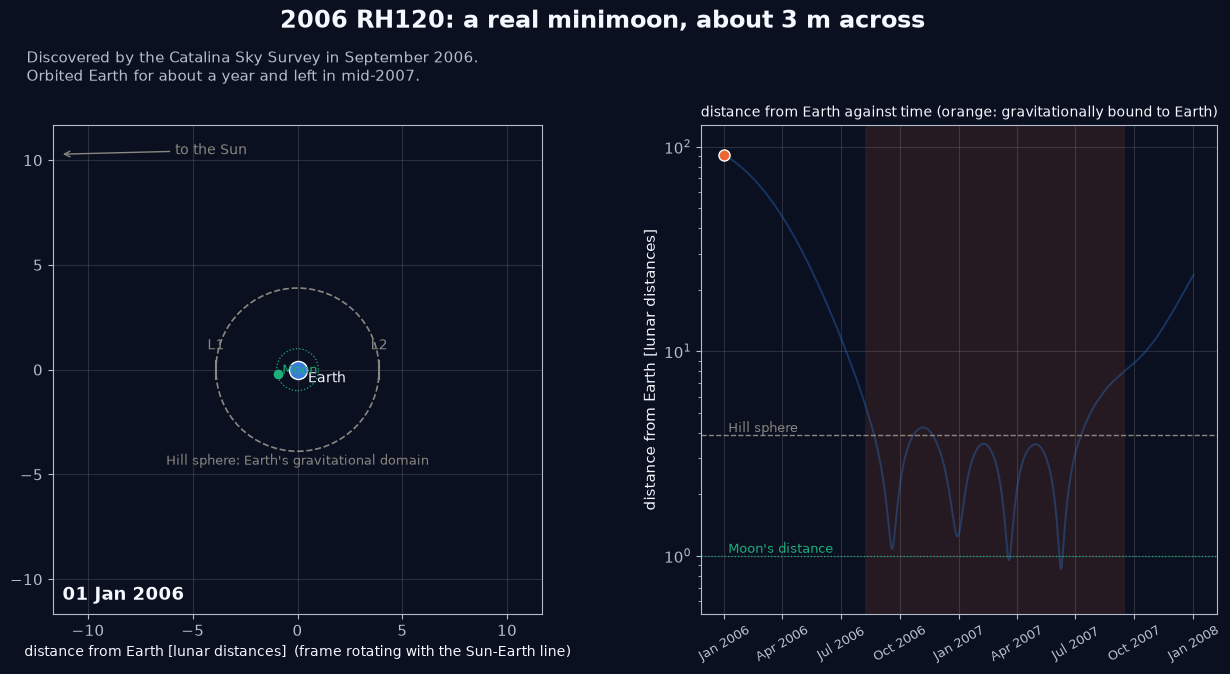

In [8]:
def make_rotating_animation(name, seconds=20, fps=24):
    traj = trajectories[name]
    rot_obj, rot_moon = rotating_frame(traj)
    x, y = rot_obj[:, 0] / LD_AU, rot_obj[:, 1] / LD_AU
    moon = rot_moon[:, :2] / LD_AU
    dist_LD = np.linalg.norm(geocentric(traj)[0], axis=1) / LD_AU
    rH = np.median(hill_radius(traj)) / LD_AU
    bound, dates = bound_mask(traj), traj["dates"]
    idx = np.unique(np.linspace(0, len(dates) - 1, seconds * fps).astype(int))
    half = 3.0 * rH
    story = {"2006 RH120": "Discovered by the Catalina Sky Survey in September 2006.\nOrbited Earth for about a year and left in mid-2007.",
             "2020 CD3": "Discovered by Catalina in February 2020, shortly before it left.\nIt had been orbiting Earth, unseen, since 2017.",
             "2024 PT5": "Found by ATLAS in August 2024. Bound to Earth for two months\nin late 2024 without completing a loop: a fly-through, not an orbit."}
    size = {"2006 RH120": "about 3 m across", "2020 CD3": "about 1-2 m across", "2024 PT5": "about 10 m across"}

    fig = plt.figure(figsize=(12.8, 7.2), dpi=100)
    gs = fig.add_gridspec(1, 2, width_ratios=[1.05, 1], wspace=0.25, left=0.05, right=0.98, top=0.80, bottom=0.12)
    ax, ax2 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])
    fig.suptitle(f"{name}: a real minimoon, {size[name]}", fontsize=17, fontweight="bold", y=0.96)
    fig.text(0.05, 0.905, story[name], fontsize=11, color=DARK["muted"], va="top")

    # --- static parts of the rotating-frame panel
    ax.set_aspect("equal"); ax.set_xlim(-half, half); ax.set_ylim(-half, half); ax.grid(alpha=0.2)
    hill_circle(ax, rH)
    ax.add_patch(Circle((0, 0), 1.0, fill=False, ls=":", lw=0.9, color=AQUA))     # the Moon's distance
    ax.plot([-rH, rH], [0, 0], "|", color=GREY, ms=14, mew=1.5)
    ax.text(-rH, 0.25 * rH, "L1", ha="center", color=GREY, fontsize=10); ax.text(rH, 0.25 * rH, "L2", ha="center", color=GREY, fontsize=10)
    ax.text(0, -1.03 * rH, "Hill sphere: Earth's gravitational domain", ha="center", va="top", color=GREY, fontsize=9)
    ax.plot(0, 0, "o", color="#3a7bd5", ms=13, mec="white"); ax.text(0.5, -0.6, "Earth", fontsize=10)
    ax.annotate("to the Sun", xy=(-half * 0.97, half * 0.88), xytext=(-half * 0.5, half * 0.88), fontsize=10,
                color=GREY, arrowprops=dict(arrowstyle="->", color=GREY))
    ax.set_xlabel("distance from Earth [lunar distances]  (frame rotating with the Sun-Earth line)", fontsize=10)
    # --- the artists that change
    trail, = ax.plot([], [], color=BLUE, lw=1.2, alpha=0.5)
    recent, = ax.plot([], [], color=BLUE, lw=2.2)
    dot, = ax.plot([], [], "o", color=ORANGE, ms=9, mec="white", zorder=5)
    moon_dot, = ax.plot([], [], "o", color=AQUA, ms=6, zorder=4)
    moon_lab = ax.text(0, 0, " Moon", fontsize=9, color=AQUA)
    date_txt = ax.text(0.02, 0.03, "", transform=ax.transAxes, fontsize=13, fontweight="bold")
    state_txt = ax.text(0.98, 0.03, "", transform=ax.transAxes, fontsize=12, ha="right", color=ORANGE, fontweight="bold")

    # --- distance panel
    ax2.plot(dates, dist_LD, color=BLUE, lw=1.4, alpha=0.35)
    for a, b in contiguous_runs(bound):
        ax2.axvspan(dates[a], dates[b - 1], color=ORANGE, alpha=0.12, lw=0)
    ax2.axhline(rH, color=GREY, lw=1, ls="--"); ax2.text(dates[0], rH, " Hill sphere", color=GREY, fontsize=9, va="bottom")
    ax2.axhline(1.0, color=AQUA, lw=0.9, ls=":"); ax2.text(dates[0], 1.0, " Moon's distance", color=AQUA, fontsize=9, va="bottom")
    ax2.set_yscale("log"); ax2.set_ylim(max(0.05, dist_LD.min() * 0.6), max(40, dist_LD.max() * 1.4))
    ax2.set_ylabel("distance from Earth [lunar distances]")
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y")); ax2.tick_params(axis="x", labelrotation=30, labelsize=9)
    ax2.set_title("distance from Earth against time (orange: gravitationally bound to Earth)", fontsize=10, loc="left")
    ax2.grid(alpha=0.2)
    progress, = ax2.plot([], [], color=BLUE, lw=2.0)
    dot2, = ax2.plot([], [], "o", color=ORANGE, ms=8, mec="white", zorder=5)

    def draw(k):
        i = idx[k]
        lo = max(0, i - int(30 / CADENCE))                # the last 30 days drawn brighter
        trail.set_data(x[:i + 1], y[:i + 1]); recent.set_data(x[lo:i + 1], y[lo:i + 1]); dot.set_data([x[i]], [y[i]])
        moon_dot.set_data([moon[i, 0]], [moon[i, 1]]); moon_lab.set_position((moon[i, 0], moon[i, 1]))
        date_txt.set_text(dates[i].strftime("%d %b %Y")); state_txt.set_text("bound to Earth" if bound[i] else "")
        progress.set_data(dates[:i + 1], dist_LD[:i + 1]); dot2.set_data([dates[i]], [dist_LD[i]])
        return trail, recent, dot, moon_dot, moon_lab, date_txt, state_txt, progress, dot2

    anim = FuncAnimation(fig, draw, frames=len(idx), interval=1000 / fps, blit=False)
    return fig, anim

fig, anim = make_rotating_animation("2006 RH120")

### Saving and showing an animation

`anim.save` renders every frame through a *writer*. `FFMpegWriter` produces an MP4 (H.264, with `yuv420p` pixels so that every browser and phone can play it); `PillowWriter` produces a GIF, which is larger and lower quality but needs no external tool and plays anywhere an image does. We also save the last frame as a PNG to use as a poster image. The helper writes all three next to each other, and `show_video` embeds the MP4 in the notebook (as `anim.to_html5_video()` would, but reusing the file we just wrote instead of rendering everything twice).

The files go to `../animations/`, which in the documentation repository is the folder the web page serves them from.

In [9]:
OUT_DIR = Path("../animations")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def save_animation(fig, anim, stem, fps=24, gif_fps=12, gif_dpi=64):
    stem = OUT_DIR / stem
    tic = time.time()
    anim.save(f"{stem}.mp4", writer=FFMpegWriter(fps=fps, codec="h264", bitrate=-1,
                                                 extra_args=["-pix_fmt", "yuv420p", "-crf", "24"]), dpi=100)
    anim.save(f"{stem}.gif", writer=PillowWriter(fps=gif_fps), dpi=gif_dpi)
    fig.savefig(f"{stem}.png", dpi=100)                  # the last rendered frame, as a poster image
    sizes = {ext: os.path.getsize(f"{stem}.{ext}") / 1e6 for ext in ("mp4", "gif", "png")}
    print(f"{stem.name}: mp4 {sizes['mp4']:.1f} MB, gif {sizes['gif']:.1f} MB, png {sizes['png']:.2f} MB "
          f"({time.time() - tic:.0f} s)")
    return stem

def show_video(stem, width=960):
    import base64
    data = base64.b64encode(Path(f"{stem}.mp4").read_bytes()).decode()
    return HTML(f'<video controls loop muted playsinline width="{width}" '
                f'src="data:video/mp4;base64,{data}"></video>')

stem = save_animation(fig, anim, "minimoon_2006_RH120_rotating")
plt.close(fig)
show_video(stem)

minimoon_2006_RH120_rotating: mp4 0.3 MB, gif 4.0 MB, png 0.11 MB (110 s)


# Step 8: A Heliocentric Camera

The rotating frame is the physicist's view. For an audience the more intuitive story is the heliocentric one: an asteroid on an orbit almost identical to Earth's slowly catches up with us, is caught, loops around for a year, and drifts away. Told at a fixed scale that story is invisible (Step 5, panel 1), so this animation moves the camera: it starts on the whole orbit, glides in to follow Earth as the asteroid approaches, holds on Earth through the bound phase — where, with the axes still fixed in space, the loops appear as a slowly turning rosette — and pulls back out after the release. A locator inset shows the full view with the current window.

Two techniques are worth taking from the code:

- **A zoom schedule.** `zoom(t)` is a number between 0 (whole orbit) and 1 (three Hill radii around Earth), ramped smoothly with a `smoothstep` around the start and end of the bound interval. The half-width of the view is then interpolated *logarithmically* between the two scales, so the zoom feels uniform.
- **Following a moving target.** During the zoom the camera centre slides from the Sun to Earth, always keeping both Earth and the asteroid in frame, and once locked on Earth the trails are drawn *relative to Earth's current position* so the rosette does not smear across the screen.

In [10]:
def smoothstep(x):
    x = np.clip(x, 0, 1)
    return x * x * (3 - 2 * x)

def make_heliocentric_animation(name, seconds=30, fps=24):
    traj = trajectories[name]
    ro, re_, rm = (traj[k] - traj["r_sun"] for k in ("r_obj", "r_earth", "r_moon"))
    rH = np.median(hill_radius(traj))
    bound, dates = bound_mask(traj), traj["dates"]
    t_days = traj["jd"] - traj["jd"][0]
    b0, b1 = t_days[np.argmax(bound)], t_days[len(bound) - 1 - np.argmax(bound[::-1])]   # first and last bound day
    idx = np.unique(np.linspace(0, len(dates) - 1, seconds * fps).astype(int))
    size = {"2006 RH120": "about 3 m across", "2020 CD3": "about 1-2 m across", "2024 PT5": "about 10 m across"}
    short = name.split()[1]

    def zoom(t):     # 0 = whole orbit centred on the Sun, 1 = 3 Hill radii centred on Earth
        return smoothstep((t - (b0 - 110)) / 70.0) * (1 - smoothstep((t - (b1 + 20)) / 70.0))

    fig = plt.figure(figsize=(12.8, 7.2), dpi=100)
    ax = fig.add_axes([0.03, 0.06, 0.62, 0.86]); ax.set_aspect("equal"); ax.grid(alpha=0.15)
    ins = fig.add_axes([0.70, 0.55, 0.28, 0.37]); ins.set_aspect("equal"); ins.set_xticks([]); ins.set_yticks([])
    ins.plot(0, 0, "o", color=YELLOW, ms=10); ins.plot(re_[:, 0], re_[:, 1], color=BLUE, lw=0.8, alpha=0.5)
    ins.plot(ro[:, 0], ro[:, 1], color=ORANGE, lw=0.8, alpha=0.7); ins.set_xlim(-1.35, 1.35); ins.set_ylim(-1.35, 1.35)
    ins.set_title("the whole picture", fontsize=10, color=DARK["muted"])
    ins_e, = ins.plot([], [], "o", color=BLUE, ms=6); ins_o, = ins.plot([], [], "o", color=ORANGE, ms=5)
    window = Rectangle((0, 0), 1, 1, fill=False, ec=DARK["ink"], lw=1.2); ins.add_patch(window)
    fig.text(0.70, 0.47, f"{name}, {size[name]}", fontsize=15, fontweight="bold")
    msg = fig.text(0.70, 0.43, "", fontsize=12, color=DARK["muted"], va="top", linespacing=1.35)
    date_txt = fig.text(0.70, 0.12, "", fontsize=16, fontweight="bold"); scale_txt = fig.text(0.70, 0.08, "", fontsize=11, color=DARK["muted"])
    ax.set_xlabel("distance from the Sun [AU]"); ax.set_ylabel("[AU]")
    ax.plot(0, 0, "o", color=YELLOW, ms=14, zorder=3); ax.text(0, 0, "  Sun", color=YELLOW, fontsize=11)
    ax.plot(re_[:, 0], re_[:, 1], color=BLUE, lw=0.8, alpha=0.35)
    trail, = ax.plot([], [], color=ORANGE, lw=1.0, alpha=0.45); recent, = ax.plot([], [], color=ORANGE, lw=2.2)
    e_trail, = ax.plot([], [], color=BLUE, lw=1.4, alpha=0.6)
    earth, = ax.plot([], [], "o", color=BLUE, ms=11, mec="white", zorder=5); moon, = ax.plot([], [], "o", color=AQUA, ms=5, zorder=4)
    obj, = ax.plot([], [], "o", color=ORANGE, ms=8, mec="white", zorder=6)
    hill = Circle((0, 0), rH, fill=False, ls="--", lw=1.2, ec=DARK["muted"], alpha=0.0); ax.add_patch(hill)
    e_lab = ax.text(0, 0, "", color=BLUE, fontsize=11); o_lab = ax.text(0, 0, "", color=ORANGE, fontsize=11)
    messages = [(0.0, "Two years around the Sun, axes fixed in space.\nThe asteroid (orange) is on an orbit almost\nidentical to Earth's: at this scale the two\npaths lie on top of each other, and the\nasteroid slowly catches up with Earth."),
                (b0 - 110, "Zooming in towards Earth as the asteroid\ncatches up ..."),
                (b0 - 20, "Inside Earth's Hill sphere (dashed) its speed\nrelative to Earth is so low that Earth holds\non to it. With the axes fixed in space the\nloops trace a slowly turning rosette."),
                (b1 + 20, "Released. Pulling back out: seen from the\nSun, nothing much happened. The asteroid\nfell slightly behind Earth and carries on\nalong its own orbit.")]

    def draw(k):
        i = idx[k]; t = t_days[i]; z = zoom(t)
        half = np.exp((1 - z) * np.log(1.3) + z * np.log(3.0 * rH))
        # camera centre: the Sun while the frame can hold both Sun and Earth, then sliding along the Sun-Earth line
        # so that Earth sits at 85% of the half-width, ending on Earth itself; never shrink the frame so far that the
        # asteroid leaves it
        r_e, keep = np.hypot(re_[i, 0], re_[i, 1]), 0.85
        for _ in range(3):
            f = 0.0 if half >= r_e / keep else 1.0 - keep * half / r_e
            f = (1 - z) * f + z
            cx, cy = f * re_[i, 0], f * re_[i, 1]
            need = max(abs(ro[i, 0] - cx), abs(ro[i, 1] - cy)) / keep
            if need <= half:
                break
            half = need
        ax.set_xlim(cx - half, cx + half); ax.set_ylim(cy - half, cy + half)
        lo = max(0, i - int(120 / CADENCE))
        shift = z * (re_[:i + 1] - re_[i])                # as the camera locks on Earth, subtract Earth's own motion
        tro, tre = ro[:i + 1] - shift, re_[:i + 1] - shift
        trail.set_data(tro[:, 0], tro[:, 1]); recent.set_data(tro[lo:, 0], tro[lo:, 1])
        e_trail.set_data(tre[lo:, 0], tre[lo:, 1]); e_trail.set_alpha(0.6 * (1 - z))
        earth.set_data([re_[i, 0]], [re_[i, 1]]); obj.set_data([ro[i, 0]], [ro[i, 1]])
        moon.set_data([rm[i, 0]], [rm[i, 1]]); moon.set_alpha(z)
        hill.center = (re_[i, 0], re_[i, 1]); hill.set_alpha(min(1.0, 2 * z))
        e_lab.set_position((re_[i, 0] - 0.16 * half, re_[i, 1] - 0.09 * half)); e_lab.set_text("Earth")
        o_lab.set_position((ro[i, 0] + 0.03 * half, ro[i, 1] + 0.04 * half)); o_lab.set_text(short if z > 0.5 else "")
        ins_e.set_data([re_[i, 0]], [re_[i, 1]]); ins_o.set_data([ro[i, 0]], [ro[i, 1]])
        window.set_bounds(cx - half, cy - half, 2 * half, 2 * half)
        date_txt.set_text(dates[i].strftime("%d %b %Y"))
        scale_txt.set_text(f"window: {2 * half * AU_KM / 1e6:.1f} million km across" + ("   ·   bound to Earth" if bound[i] else ""))
        msg.set_text([m for t0, m in messages if t >= t0][-1])
        return trail, recent, e_trail, earth, obj, moon, hill, e_lab, o_lab, ins_e, ins_o, window, date_txt, scale_txt, msg

    anim = FuncAnimation(fig, draw, frames=len(idx), interval=1000 / fps, blit=False)
    return fig, anim

fig, anim = make_heliocentric_animation("2006 RH120")
stem = save_animation(fig, anim, "minimoon_2006_RH120_heliocentric", gif_fps=8, gif_dpi=50)
plt.close(fig)
show_video(stem)

minimoon_2006_RH120_heliocentric: mp4 2.1 MB, gif 10.2 MB, png 0.09 MB (137 s)


# Step 9: Rendering the Whole Set

With the two functions in hand, the other objects are a loop. We render the rotating-frame animation for 2020 CD3 and 2024 PT5 and show their poster frames here (the videos are in `../animations/` and on the [animations page](https://docs.minorplanetcenter.net/tutorials/animation_tutorials/) of this site). Each object gets a slightly different treatment from the code automatically — 2020 CD3's three-and-a-half-year window, 2024 PT5's brief fly-through — because everything is derived from the trajectory.

A note on file sizes: an MP4 of 20 s is about 1 MB; the GIF of the same animation is three to four times larger at a quarter of the resolution. Use MP4 (with `<video>`) on web pages and keep GIFs for places that cannot play video.

minimoon_2020_CD3_rotating: mp4 0.3 MB, gif 5.9 MB, png 0.12 MB (186 s)


minimoon_2024_PT5_rotating: mp4 0.2 MB, gif 3.7 MB, png 0.10 MB (168 s)


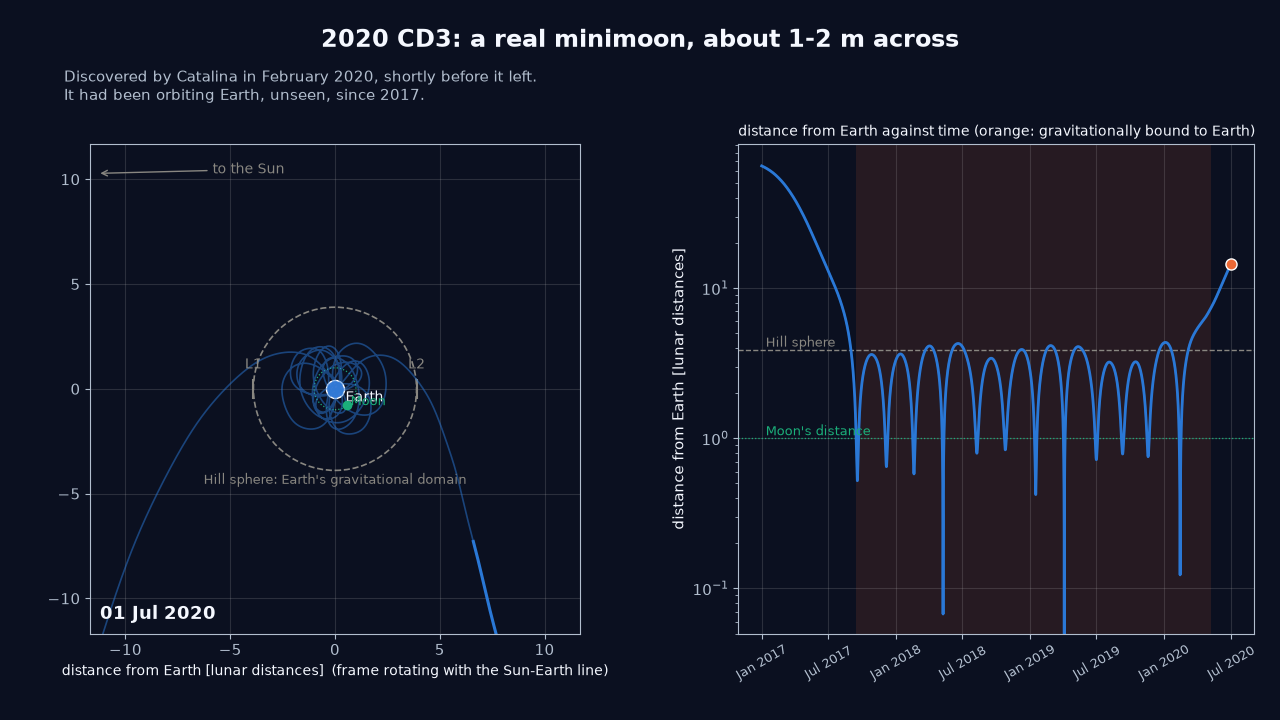

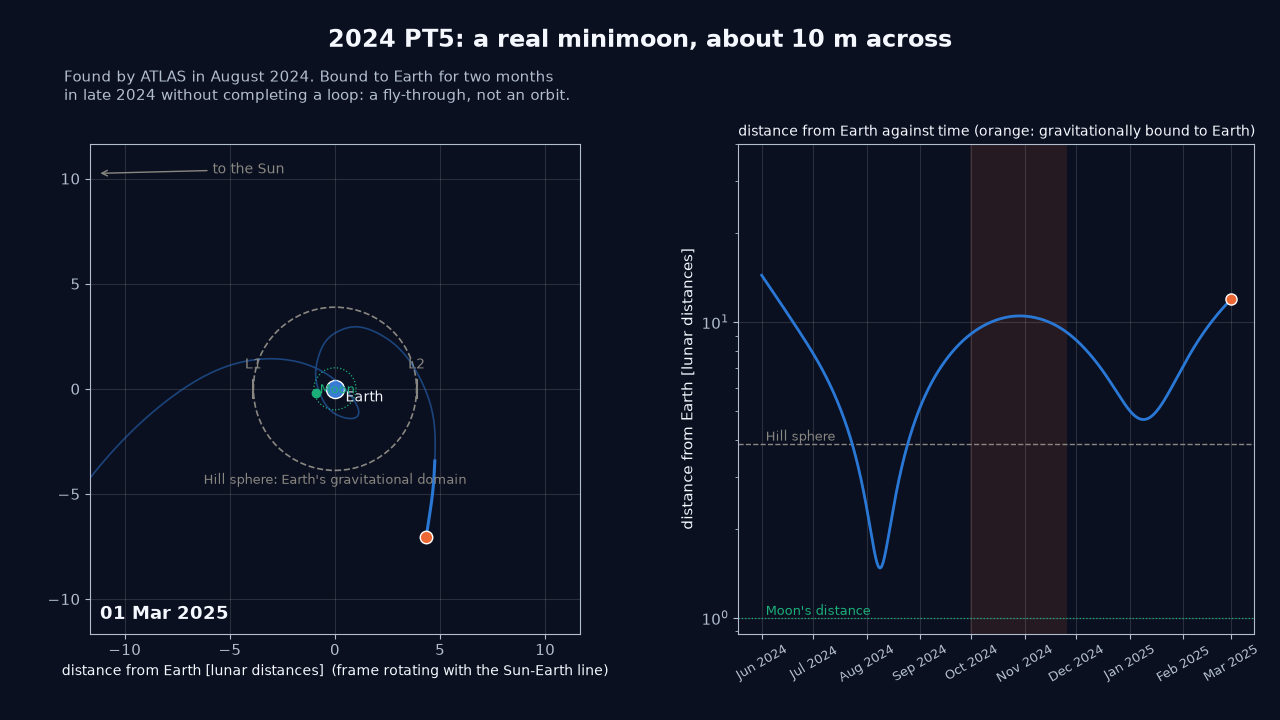

In [11]:
posters = {}
for name in ["2020 CD3", "2024 PT5"]:
    fig, anim = make_rotating_animation(name)
    posters[name] = save_animation(fig, anim, f"minimoon_{name.replace(' ', '_')}_rotating")
    plt.close(fig)

for name, stem in posters.items():
    display(Image(filename=f"{stem}.png", width=800))

# Summary

In this tutorial we:

1. **Fetched** the orbits of three real minimoons — 2006 RH120, 2020 CD3 and 2024 PT5 — from the MPC Orbits API
2. **Simulated** their capture windows with ASSIST, integrating forwards and backwards from the catalogue epoch with the Moon included, and saw why the epoch matters when reconstructing an old event
3. **Classified** the events with the standard diagnostics — geocentric energy, the Hill sphere, revolutions in the rotating frame — reproducing the published verdicts: two temporarily captured orbiters and one fly-by
4. **Compared** three frames of reference and found that the Sun–Earth rotating frame is the one in which captures are legible
5. **Built** two animations with `FuncAnimation`: a rotating-frame view with a distance panel, and a heliocentric camera with a zoom schedule
6. **Rendered** them as MP4, GIF and poster PNG for embedding on a web page

### Ideas to extend

- Add the next minimoon: the code needs only a designation and a window. Candidates the MPC has catalogued include 2022 NX1 (a fly-by in 2022, due back in 2051) and 1991 VG
- Animate a *synthetic* capture: draw a near-Earth orbit at random, propagate it with ASSIST, and keep the ones that become bound — the Monte Carlo approach used to estimate the steady-state population of minimoons
- Add a third panel to the rotating-frame animation showing the geocentric energy crossing zero

### Further Resources

- [Granvik, Vaubaillon & Jedicke (2012), *The population of natural Earth satellites*, Icarus 218, 262](https://ui.adsabs.harvard.edu/abs/2012Icar..218..262G)
- [Fedorets, Granvik & Jedicke (2017), *Orbit and size distributions for asteroids temporarily captured by the Earth-Moon system*, Icarus 285, 83](https://ui.adsabs.harvard.edu/abs/2017Icar..285...83F)
- [Kwiatkowski et al. (2009), *Photometry of 2006 RH120: an asteroid temporary captured into a geocentric orbit*, A&A 495, 967](https://ui.adsabs.harvard.edu/abs/2009A%26A...495..967K)
- [Naidu et al. (2021), *Precovery observations confirm the capture time of asteroid 2020 CD3 as Earth's minimoon*, ApJL 913, L6](https://ui.adsabs.harvard.edu/abs/2021ApJ...913L...6N)
- [de la Fuente Marcos & de la Fuente Marcos (2024), *A two-month mini-moon: 2024 PT5 captured by Earth from September to November*, RNAAS 8, 224](https://ui.adsabs.harvard.edu/abs/2024RNAAS...8..224D)
- [matplotlib animation documentation](https://matplotlib.org/stable/api/animation_api.html)
- [Working with Orbits](https://docs.minorplanetcenter.net/tutorials/orbit_tutorials/): the static tutorials this notebook builds on
- [Companion tutorial: From MPC Orbit to N-Body Simulation](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_to_rebound/)
- [Companion tutorial: Plotting Asteroid Orbits](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_plotting/)
- [Companion tutorial: Reference Frames for Solar System Dynamics](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_frames/)
- [Companion tutorial: From MPC Orbit to Ephemeris-Quality Integration with ASSIST](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_to_assist/)
- [Companion tutorial: Earth's Co-orbital Companions](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_earth_coorbitals/)
- [MPC Orbits API documentation](https://docs.minorplanetcenter.net/mpc-ops-docs/apis/get-orb/)

For questions or feedback, contact the MPC via the [Jira Helpdesk](https://mpc-service.atlassian.net/servicedesk/customer/portal/13/create/148).